# Machine Learning Aplicado ao Sistemas de Temperatura da Planta Didática de Automação Industrial SMAR-PD3

Neste código, faremos a modelagem do sistema de aquecimento da planta didárica SMAR-PD3 para diferentes vazões no tanque através de algoritmos usando técnicas avançadas de machine learning.

## Visualização dos dados

Inicialmente, devemos visualizar os dados que usaremos para treinar e validar nosso modelo. O conjunto de dados foi gerado com base na publicação Modelagem Caixa Preta do Tanque de Aquecimento da Planta Didática SMAR PD3: Uma atualização (https://www.researchgate.net/publication/334154604_Modelagem_Caixa_Preta_do_Tanque_de_Aquecimento_da_Planta_Didatica_SMAR_PD3_Uma_atualizacao). Nesta publicação, são apresentados gráficos que demonstram o processo de aquecimento do tanque para a seguinte condição: potência de 8W na bobina de aquecimento, ou seja, sinal de 20mA, vazão de 200l/h e uma curva de aquecimento baseado na temperatura do tanque. 

Essencialmente, o código deve ser capaz de interpretar os dados e replicar a curva, no caso estudando parte dela para fazer o resto. A versão final do código deve ser capaz de prever a curva em uma outra situação na planta (mais vazão e menos temperatura, etc.).

Através do uso de inteligência artificial, foi possível transcrever os gráficos em um arquivo .csv. Isso se fez necessário pois não há, na publicação e nem na monografia, o conjunto de dados necessário. Portanto, trabalharemos com o segundo dataset:

,Tempo (s),Sinal (mA),Vazão (L/h),Temperatura (°C)
0,0,0,50,20.0
1,20,20,50,20.3
2,40,20,50,20.5
3,60,20,50,20.8
4,80,20,50,21.1
...,...,...,...,...
146,2920,0,200,58.9
147,2940,0,200,59.2
148,2960,0,200,59.5
149,2980,0,200,59.7


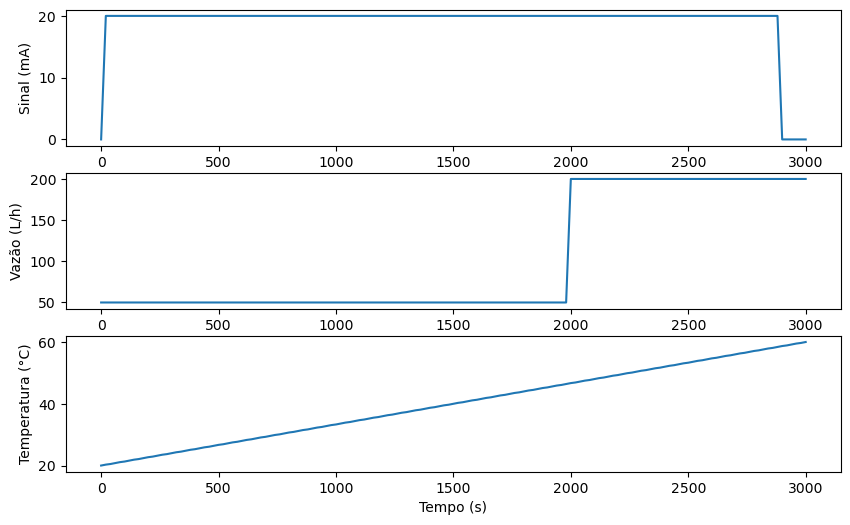

In [22]:
# Importação das bibliotecas necessárias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To suppress some warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

%matplotlib inline

# Estabelecemos a seed como uma specífica para evitar aleatoriedades desnessárias

np.random.seed(0)

# Importação do dataset

temp_data = pd.read_csv(r"C:\Users\Cauan\Documents\UFV\Projeto Planta de Pesquisa\Código\Machine Learning\Teste\dados_graficos_final.csv")

display(temp_data)

# Visualização dos dados

fig, ax = plt.subplots(3,1, figsize=(10,6))

sns.lineplot(data=temp_data, x='Tempo (s)', y='Sinal (mA)', ax = ax[0])

sns.lineplot(data=temp_data, x='Tempo (s)', y='Vazão (L/h)', ax = ax[1])

sns.lineplot(data=temp_data, x='Tempo (s)', y='Temperatura (°C)', ax = ax[2])

plt.show()

## Modelo Computacional Proposto

O modelo proposto consiste do uso da biblioteca sickit-learn para Python afim de estruturar um modelo de regressão linear que consiga representar fielmente o fenômeno observado na planta didática SMAR-PD3. A ferramenta da biblioteca escolhida é o RandomForestRegressor. 

Essa estrutura de modelo é uma forma melhorada da estrutura RandomTreeRegressor. Esta segunda consiste em um algoritmo que essencialmente divide o dataset em grupos, se especializando cada vez mais afim de buscar um padrão no dataset. Ou seja, ele faz uma pergunta inicial sobre o dataset e separa-o baseado nas possíveis respostas (sim ou não, acima ou abaixo, esquerda ou direita, etc.). 

Podemos estipular quantas perguntas exatamente o algoritmo fará, mas o balanço é delicado: perguntas de menos, e ele não encontra um padrão pertinente (underlift), perguntas demais e ele se torna extremamente especializado no dataset em estudo, mas não em futuros cenários (overfitting). 

Por isso o RandomForestRegressor é uma melhoria, pois ele gera diversas "árvores" de diferentes parâmetros e gera como predição uma média das respostas das árvores. Sendo assim, usando a monografia em estudo e as conclusões nela, foi escolhido um algoritmo regressor consideravelmente refinado para modelar o processo.

In [33]:
# Importação de bibliotecas

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Separação de features e targets

X = temp_data.drop(['Temperatura (°C)'], axis=1)
y = temp_data['Temperatura (°C)']

# Preparação do modelo

temp_model = RandomForestRegressor(random_state=1)

temp_model.fit(X,y)

# Uso de cross-validation

crssval_results = -cross_val_score(temp_model, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

print("Average MSE score (across experiments):")
print(crssval_results.mean())

Average MSE score (across experiments):
13.018688646881866


Através de ferramentas do sickit-learn, nós podemos observar o erro quadrado médio do nosso modelo (13.018...). Como na monografia em estudo não é mostrado um valor de erro/desvio que possa ser usado como referência de comparação, vamos usar uma publicação de teor similar titulada "Modelagem Caixa Preta do Tanque de Aquecimento da Planta Didática SMAR PD3: Uma atualização". Neste trabalho é apresentado o cálculo de RMSE e posteriormente R² como medidas de precisão. Buscaremos usar medidas parecidas para avaliar nosso modelo e compará-lo com os valores na publicação.

In [42]:
# Predições do modelo

from sklearn.model_selection import train_test_split

train_X,val_X, train_y,val_y = train_test_split(X,y,random_state=1,train_size=0.8)

index = temp_data.index

test_X = temp_data[list(X.columns)]

predictions = temp_model.predict(test_X)

# Cálculo do erro quadrado médio

mse = mean_squared_error(temp_data['Temperatura (°C)'], predictions)

rmse = np.sqrt(mse)
r2 = (1-rmse)*100

print('RMSE: %f' % rmse)
print('R²: %f' % r2,'%')


RMSE: 0.061484
R²: 93.851582 %
